# Deliverables Machine learning project

## Step-by-Step analysis

### 1. Setting Up the Environment

In [78]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tarfile
import os
import glob
import missingno as msno
from sklearn.preprocessing import OneHotEncoder
import plotly.express as px
import folium
from folium.plugins import MarkerCluster, HeatMap
import plotly.graph_objects as go
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
from functools import reduce




#### Configuring display settings

In [79]:
# Configuring display settings
plt.rcParams['figure.figsize'] = (12, 9)
sns.set()
sns.set_context('talk')
np.set_printoptions(threshold=500, precision=2, suppress=True)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings("ignore", category=FutureWarning)

### 2. Loading and Exploring the Housing Data

In [80]:
directory_path = "."
search_pattern = os.path.join(directory_path, "*.csv")
csv_files_names = glob.glob(search_pattern)

if not csv_files_names:
    print("Error: No CSV files found in the specified directory.")
else:
    first_file = csv_files_names[0]
    employees_data = pd.read_csv(first_file)
    print(f"Loaded initial file: {os.path.basename(first_file)}")
    
    for next_file in csv_files_names[1:]:
        next_df = pd.read_csv(next_file)
        employees_data = pd.merge(
            employees_data,
            next_df,
            on="EmployeeID",
            how='outer',
            suffixes=('', f'_{os.path.basename(next_file).replace(".csv", "")}')
        )
        print(f'Merged with: {os.path.basename(next_file)}')
    print("\n--- Merged DataFrame Information (Joined on EmployeeID) ---")

Loaded initial file: employee_survey_data.csv
Merged with: general_data.csv
Merged with: manager_survey_data.csv

--- Merged DataFrame Information (Joined on EmployeeID) ---


### 3. Understanding the Data

#### Data infos

In [81]:
print(employees_data.info())
print('number of columns:', employees_data.columns.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
 4   Age                      4410 non-null   int64  
 5   Attrition                4410 non-null   object 
 6   BusinessTravel           4410 non-null   object 
 7   Department               4410 non-null   object 
 8   DistanceFromHome         4410 non-null   int64  
 9   Education                4410 non-null   int64  
 10  EducationField           4410 non-null   object 
 11  EmployeeCount            4410 non-null   int64  
 12  Gender                   4410 non-null   object 
 13  JobLevel                 4410 non-null   int64  
 14  JobRole                 

In [82]:
# 1. Identify constant columns (noise)
# We look for columns where the number of unique values is exactly 1
constant_columns = [col for col in employees_data.columns if employees_data[col].nunique() <= 1]

print(f"Constant columns to drop: {constant_columns}")

# 2. Identify potentially unethical/sensitive columns
# We define a list of keywords usually associated with bias or privacy
sensitive_keywords = [
    'gender', 'sex', 'religion', 'race', 'ethnicity', 
    'political', 'union', 'disability', 'sexual', 'birth'
]

# We check if any column name contains one of these keywords
sensitive_columns = [
    col for col in employees_data.columns 
    if any(keyword in col.lower() for keyword in sensitive_keywords)
]

print(f"Sensitive columns detected: {sensitive_columns}")

# 3. Combine and drop
# We verify if we found columns to drop before executing the action
columns_to_drop = constant_columns + sensitive_columns

if columns_to_drop:
    employees_data = employees_data.drop(columns=columns_to_drop)
    print("Columns successfully dropped.")
else:
    print("No columns to drop found.")

# Display new shape
print('New data shape:', employees_data.shape)

Constant columns to drop: ['EmployeeCount', 'Over18', 'StandardHours']
Sensitive columns detected: ['Gender']
Columns successfully dropped.
New data shape: (4410, 25)


#### Data description

In [83]:
employees_data.describe()

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,DistanceFromHome,Education,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating
count,4410.00,4385.00,4390.00,4372.00,4410.00,4410.00,4410.00,4410.00,4410.00,4391.00,4410.00,4410.00,4401.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00
mean,2205.50,2.72,2.73,2.76,36.92,9.19,2.91,2.06,65029.31,2.69,15.21,0.79,11.28,2.80,7.01,2.19,4.12,2.73,3.15
std,1273.20,1.09,1.10,0.71,9.13,8.11,1.02,1.11,47068.89,2.50,3.66,0.85,7.78,1.29,6.13,3.22,3.57,0.71,0.36
min,1.00,1.00,1.00,1.00,18.00,1.00,1.00,1.00,10090.00,0.00,11.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3.00
25%,1103.25,2.00,2.00,2.00,30.00,2.00,2.00,1.00,29110.00,1.00,12.00,0.00,6.00,2.00,3.00,0.00,2.00,2.00,3.00
50%,2205.50,3.00,3.00,3.00,36.00,7.00,3.00,2.00,49190.00,2.00,14.00,1.00,10.00,3.00,5.00,1.00,3.00,3.00,3.00
75%,3307.75,4.00,4.00,3.00,43.00,14.00,4.00,3.00,83800.00,4.00,18.00,1.00,15.00,3.00,9.00,3.00,7.00,3.00,3.00
max,4410.00,4.00,4.00,4.00,60.00,29.00,5.00,5.00,199990.00,9.00,25.00,3.00,40.00,6.00,40.00,15.00,17.00,4.00,4.00


#### Data head

In [84]:
employees_data.head()

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating
0,1,3.00,4.00,2.00,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Healthcare Representative,Married,131160,1.00,11,0,1.00,6,1,0,0,3,3
1,2,3.00,2.00,4.00,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,Research Scientist,Single,41890,0.00,23,1,6.00,3,5,1,4,2,4
2,3,2.00,2.00,1.00,32,No,Travel_Frequently,Research & Development,17,4,Other,4,Sales Executive,Married,193280,1.00,15,3,5.00,2,5,0,3,3,3
3,4,4.00,4.00,3.00,38,No,Non-Travel,Research & Development,2,5,Life Sciences,3,Human Resources,Married,83210,3.00,11,3,13.00,5,8,7,5,2,3
4,5,4.00,1.00,3.00,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,Sales Executive,Single,23420,4.00,12,2,9.00,2,6,0,4,3,3


#### What does the columns contains ?

In [85]:
for col in employees_data.columns:
    print("Name of the column", col)
    print(employees_data[col].value_counts())
    print("-------------------------------------")

Name of the column EmployeeID
EmployeeID
1       1
2       1
3       1
4       1
5       1
       ..
4406    1
4407    1
4408    1
4409    1
4410    1
Name: count, Length: 4410, dtype: int64
-------------------------------------
Name of the column EnvironmentSatisfaction
EnvironmentSatisfaction
3.00    1350
4.00    1334
2.00     856
1.00     845
Name: count, dtype: int64
-------------------------------------
Name of the column JobSatisfaction
JobSatisfaction
4.00    1367
3.00    1323
1.00     860
2.00     840
Name: count, dtype: int64
-------------------------------------
Name of the column WorkLifeBalance
WorkLifeBalance
3.00    2660
2.00    1019
4.00     454
1.00     239
Name: count, dtype: int64
-------------------------------------
Name of the column Age
Age
35    234
34    231
31    207
36    207
29    204
32    183
30    180
33    174
38    174
40    171
37    150
27    144
28    144
42    138
39    126
45    123
41    120
26    117
46     99
44     99
43     96
50     90
25     

### 4. Handling Missing values

#### Visualize missing data

In [86]:
employees_data.isnull().sum()

EmployeeID                  0
EnvironmentSatisfaction    25
JobSatisfaction            20
WorkLifeBalance            38
Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
JobLevel                    0
JobRole                     0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked         19
PercentSalaryHike           0
StockOptionLevel            0
TotalWorkingYears           9
TrainingTimesLastYear       0
YearsAtCompany              0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
JobInvolvement              0
PerformanceRating           0
dtype: int64

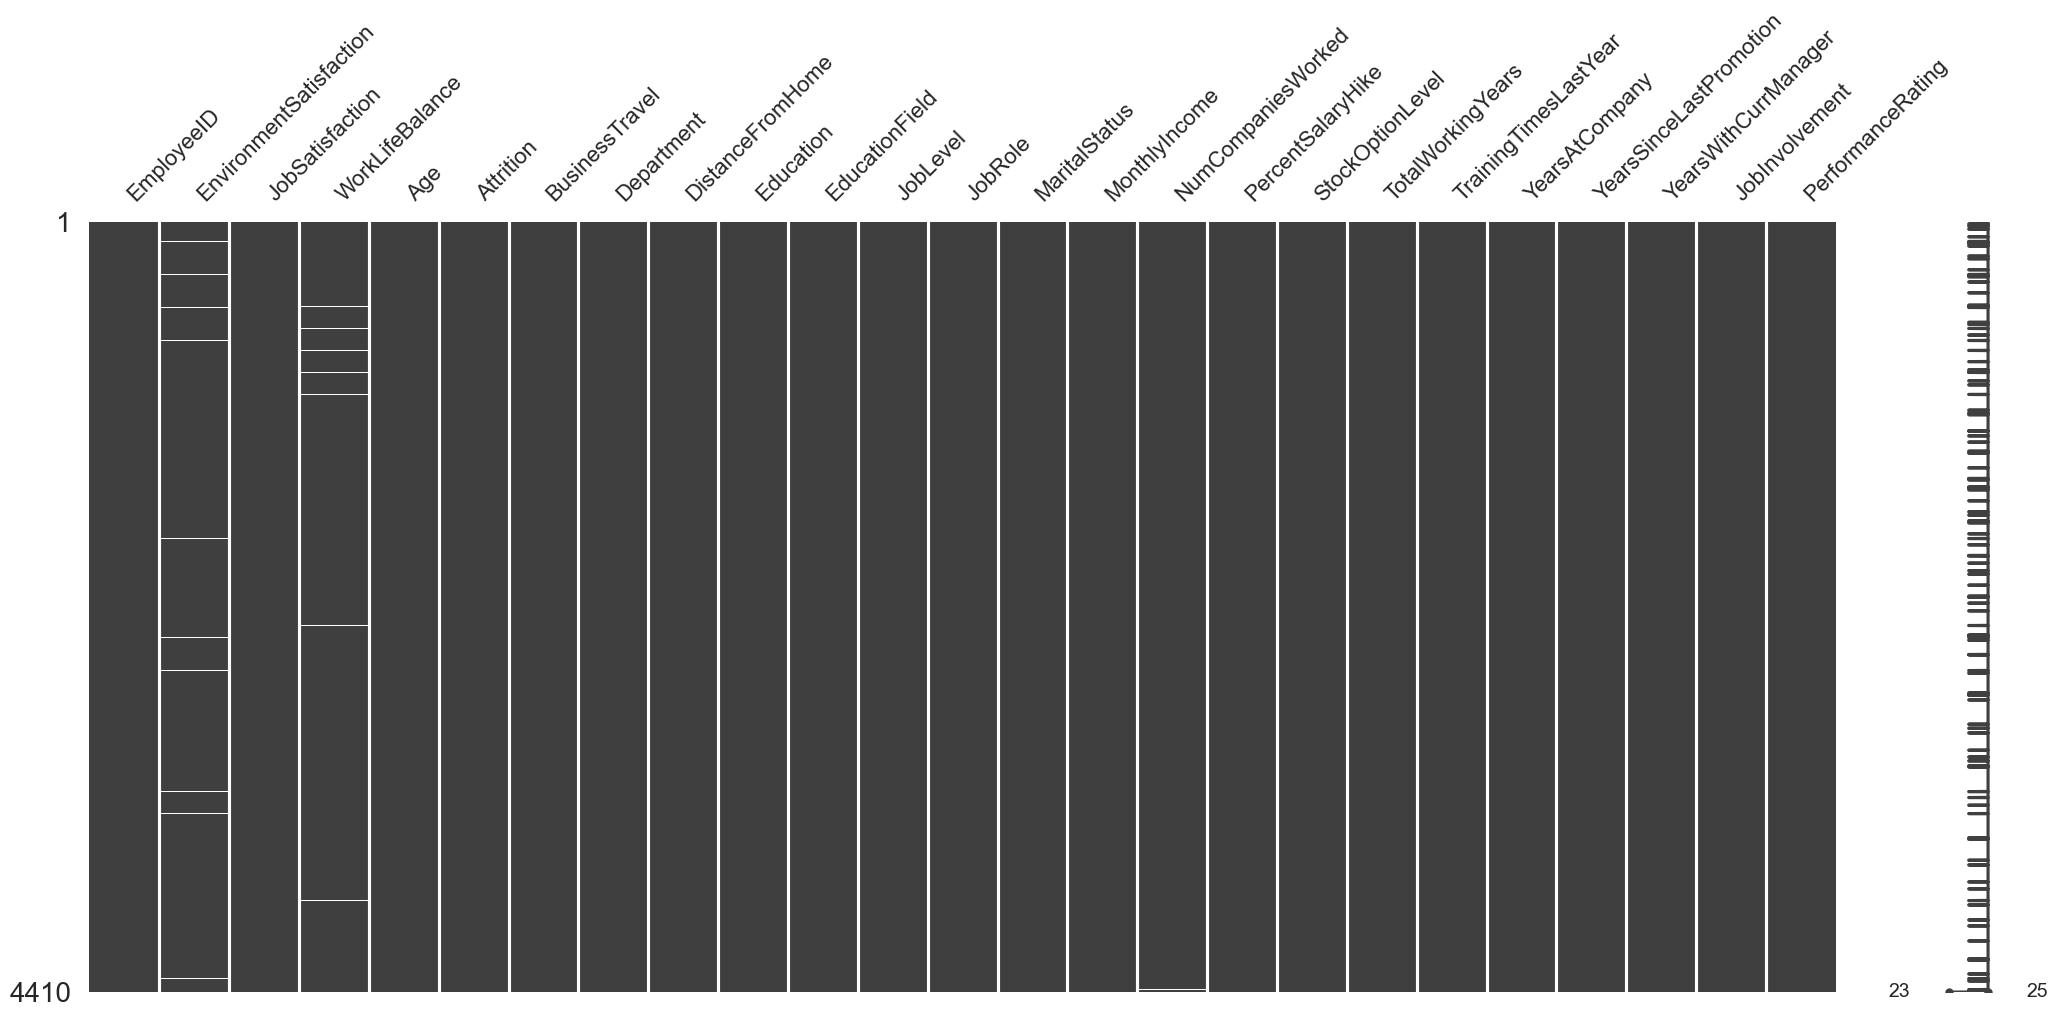

In [87]:
msno.matrix(employees_data)
plt.show()

#### Impute missing values

##### For numerical columns, use median imputation

In [88]:
numerical_cols = employees_data.select_dtypes(include=['int64', 'float64']).columns
employees_data[numerical_cols] = employees_data[numerical_cols].fillna(employees_data[numerical_cols].median())

##### For categorical columns, use mode imputation

In [89]:
categorical_cols = employees_data.select_dtypes(include=['object']).columns
employees_data[categorical_cols] = employees_data[categorical_cols].fillna(employees_data[categorical_cols].mode().iloc[0])

##### Verifying that there are no more missing values

In [90]:
employees_data.isnull().sum()

EmployeeID                 0
EnvironmentSatisfaction    0
JobSatisfaction            0
WorkLifeBalance            0
Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
JobLevel                   0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
PercentSalaryHike          0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
JobInvolvement             0
PerformanceRating          0
dtype: int64

### 5. Univariate Analysis

#### Univariate analysis for numerical features

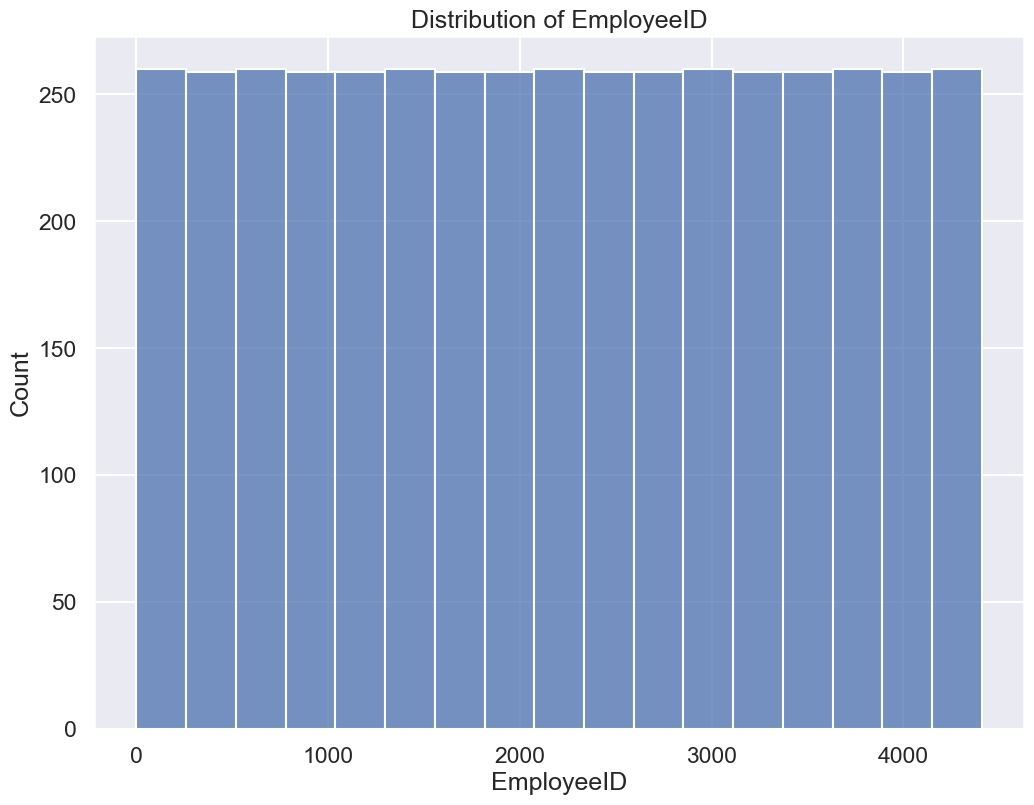

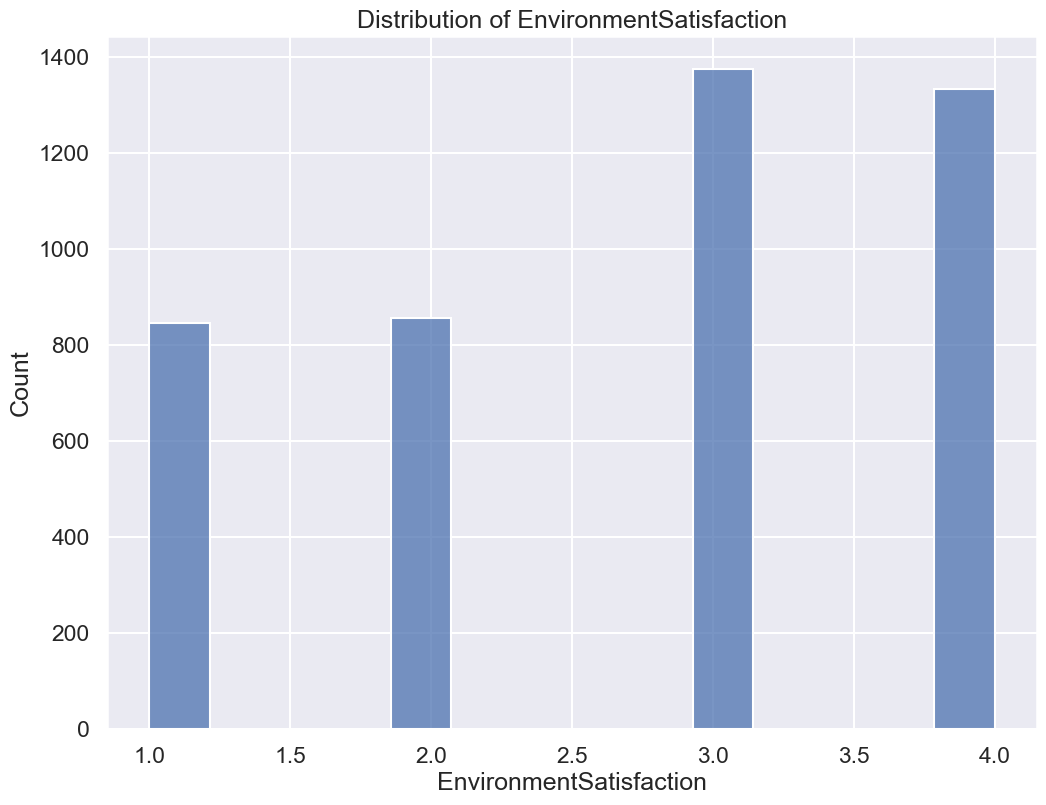

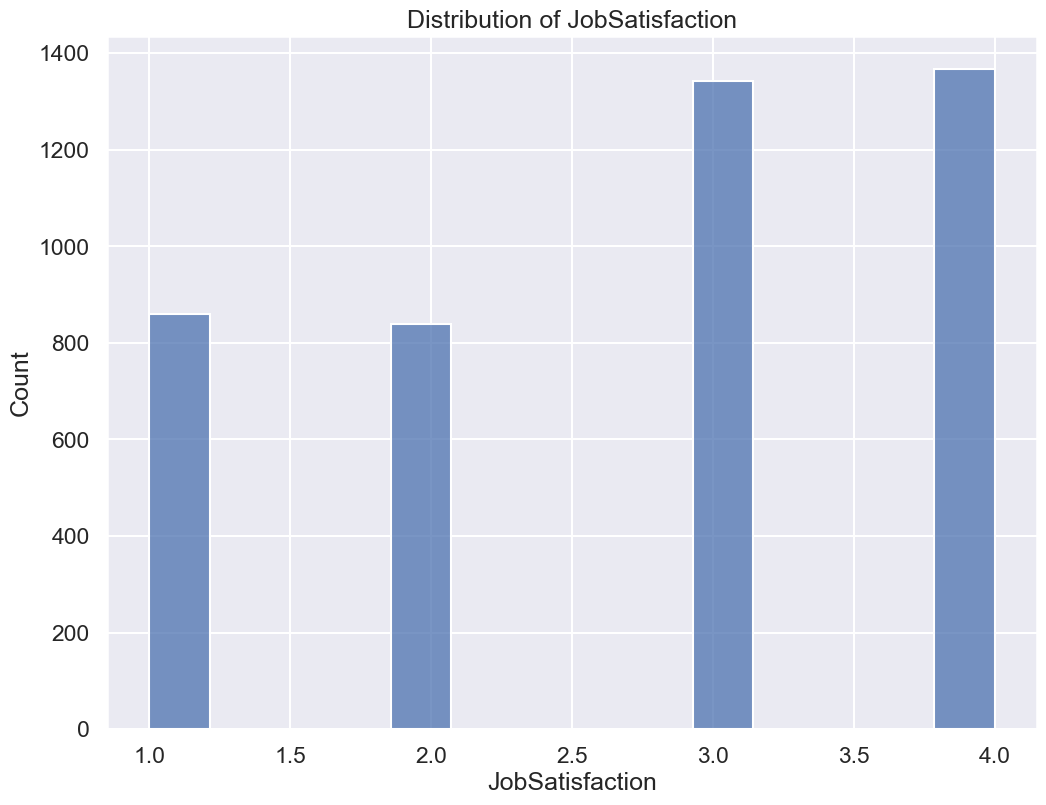

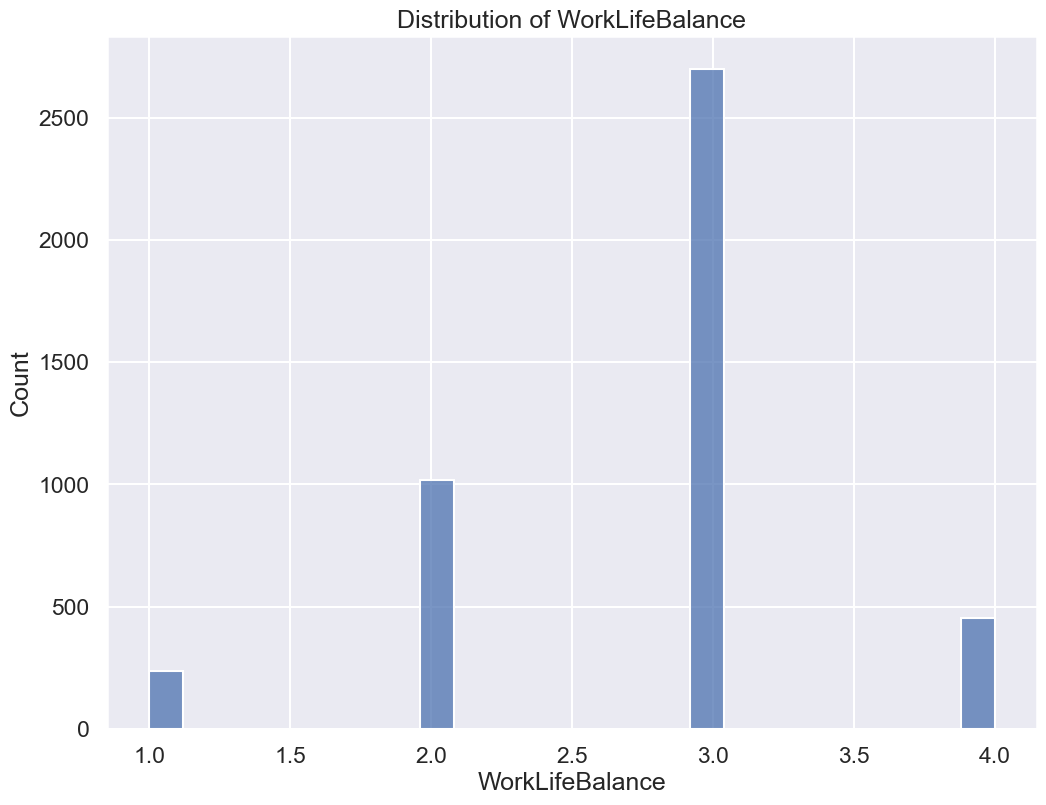

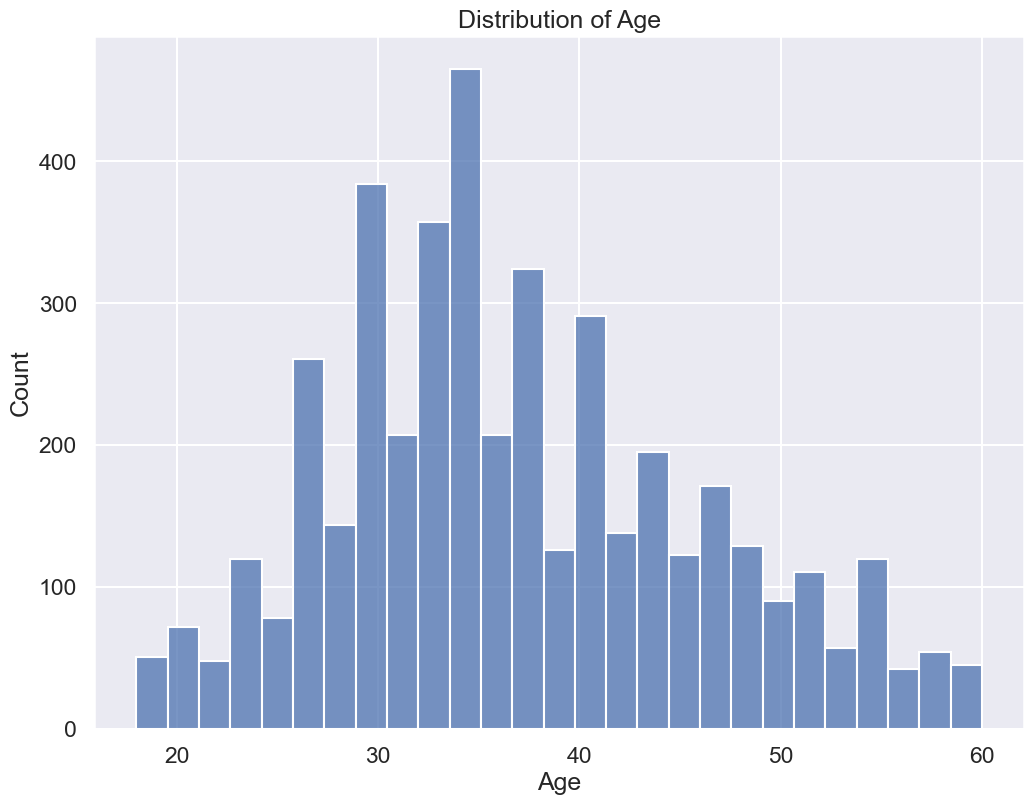

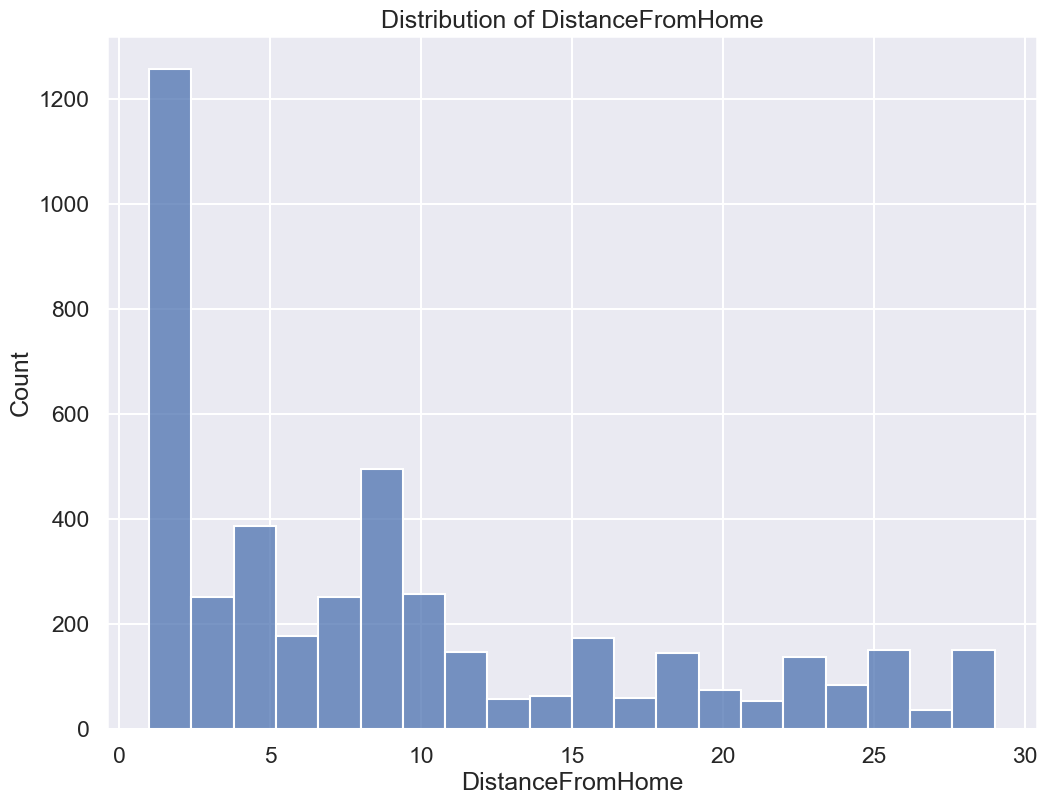

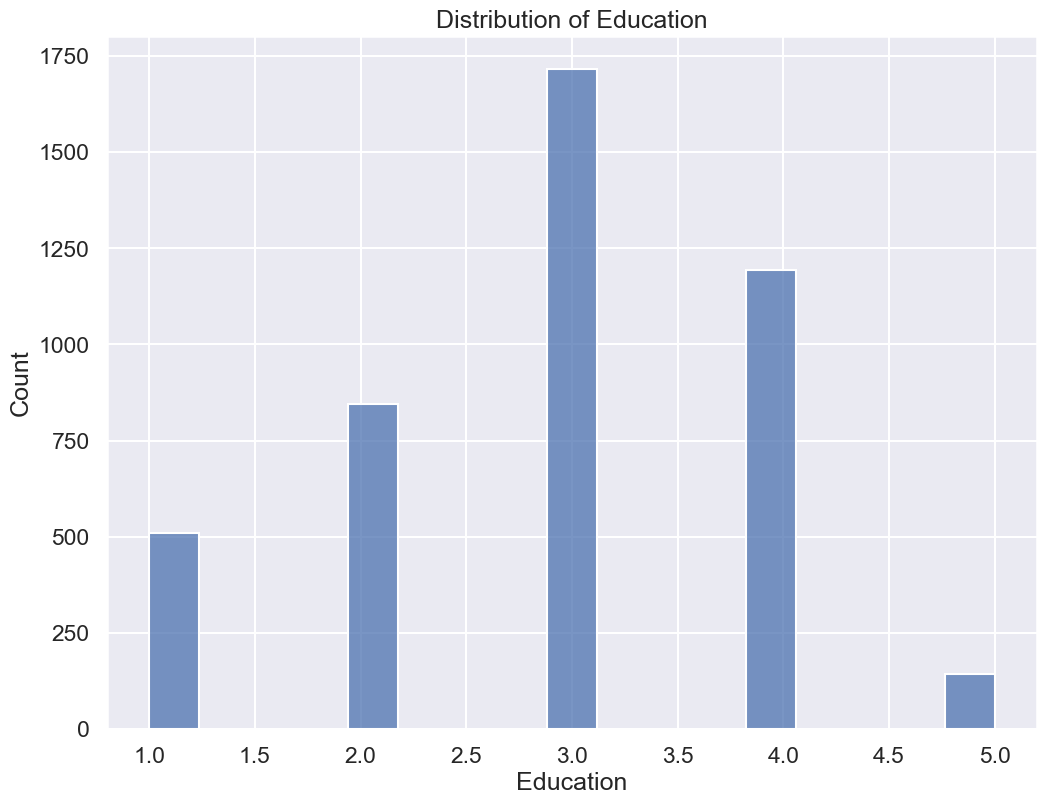

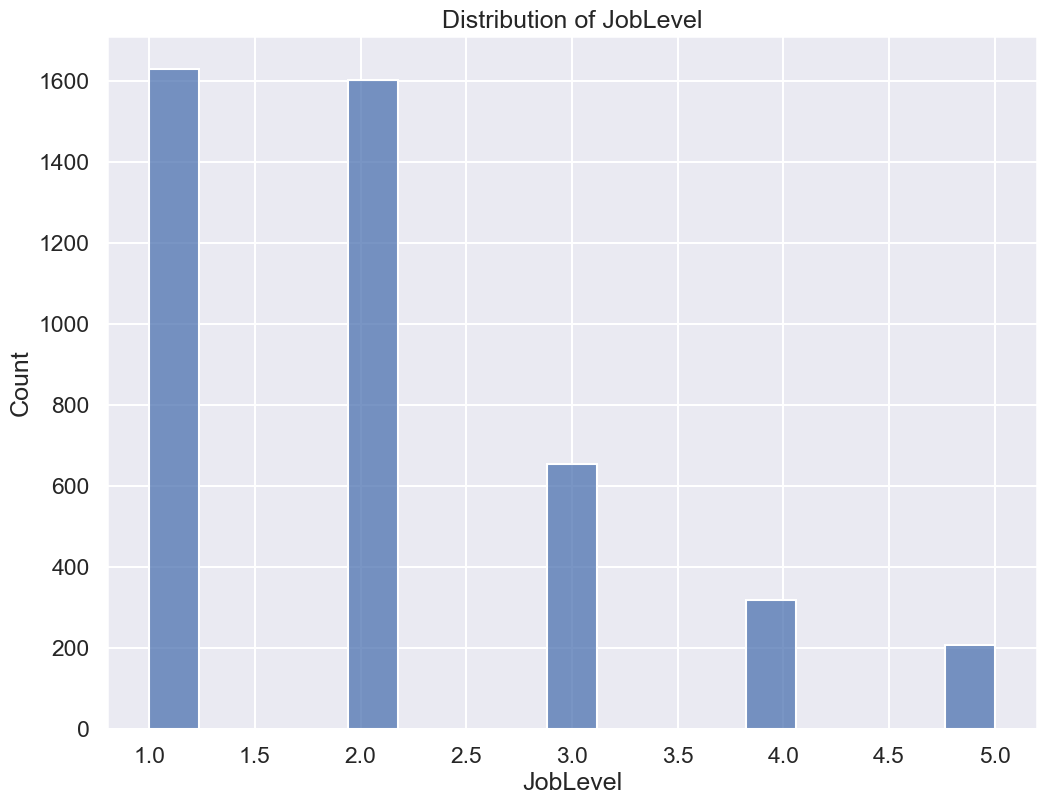

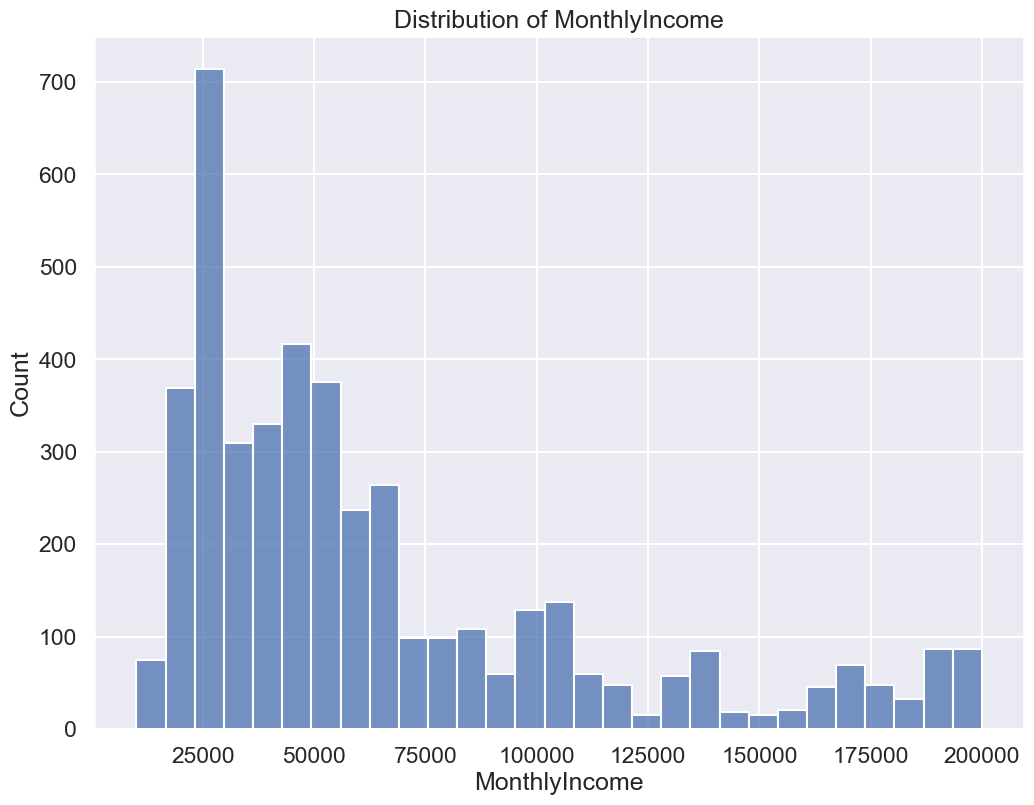

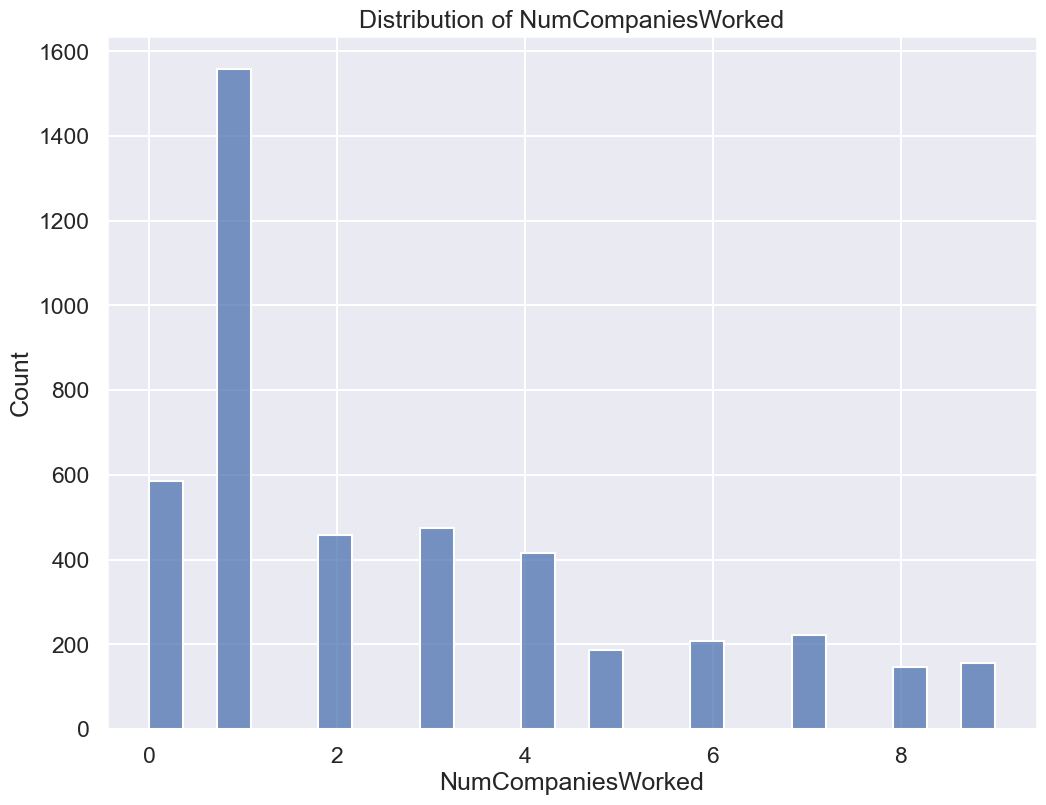

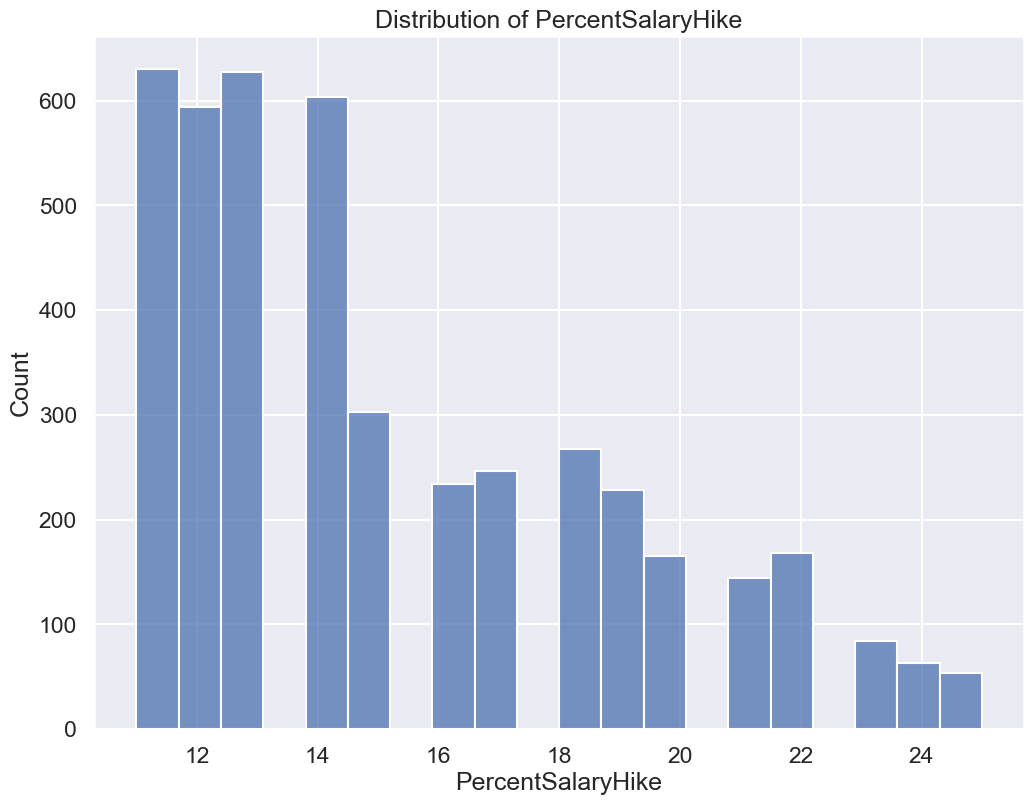

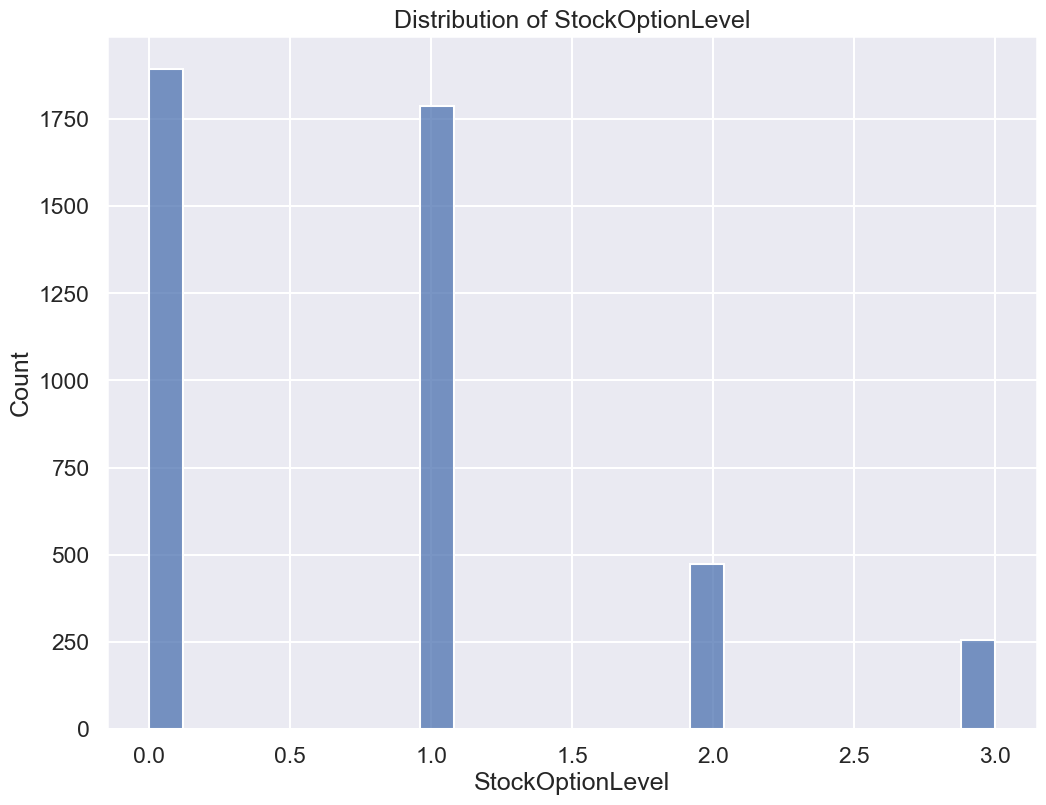

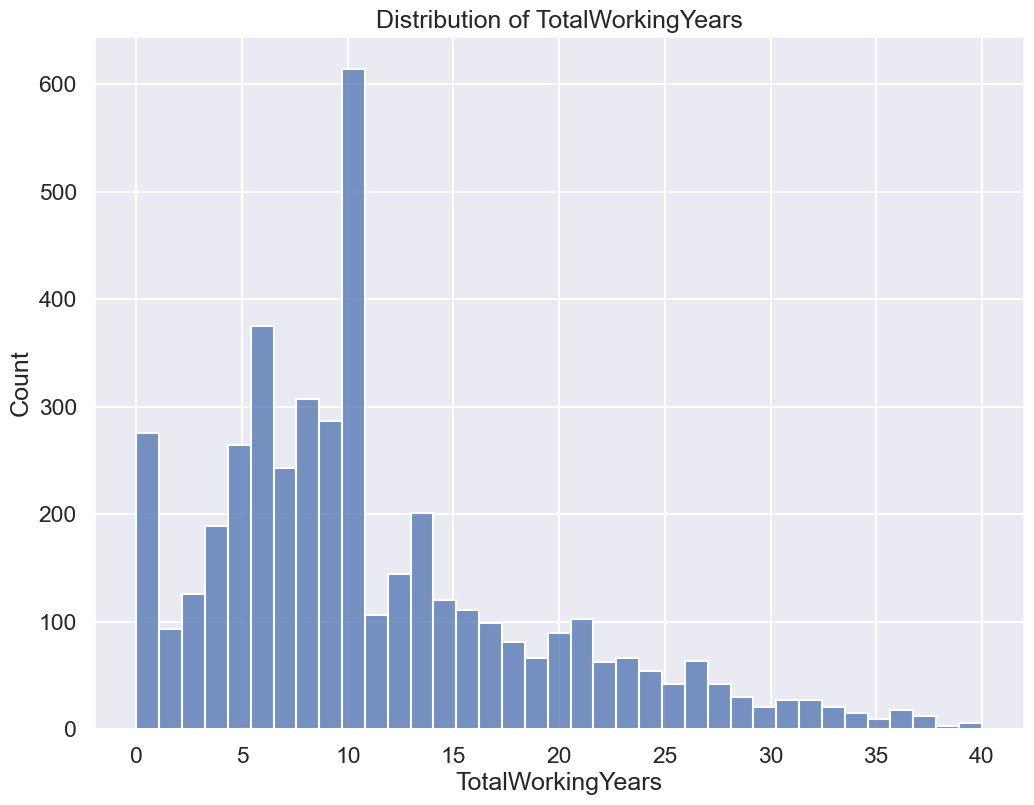

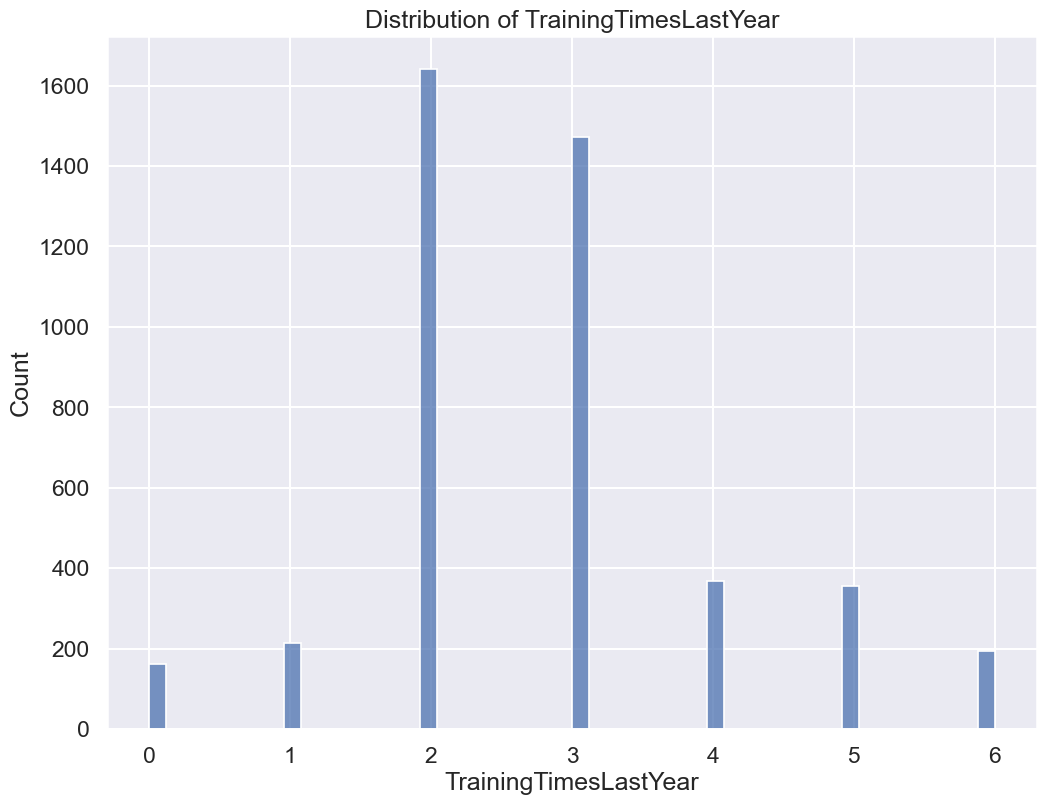

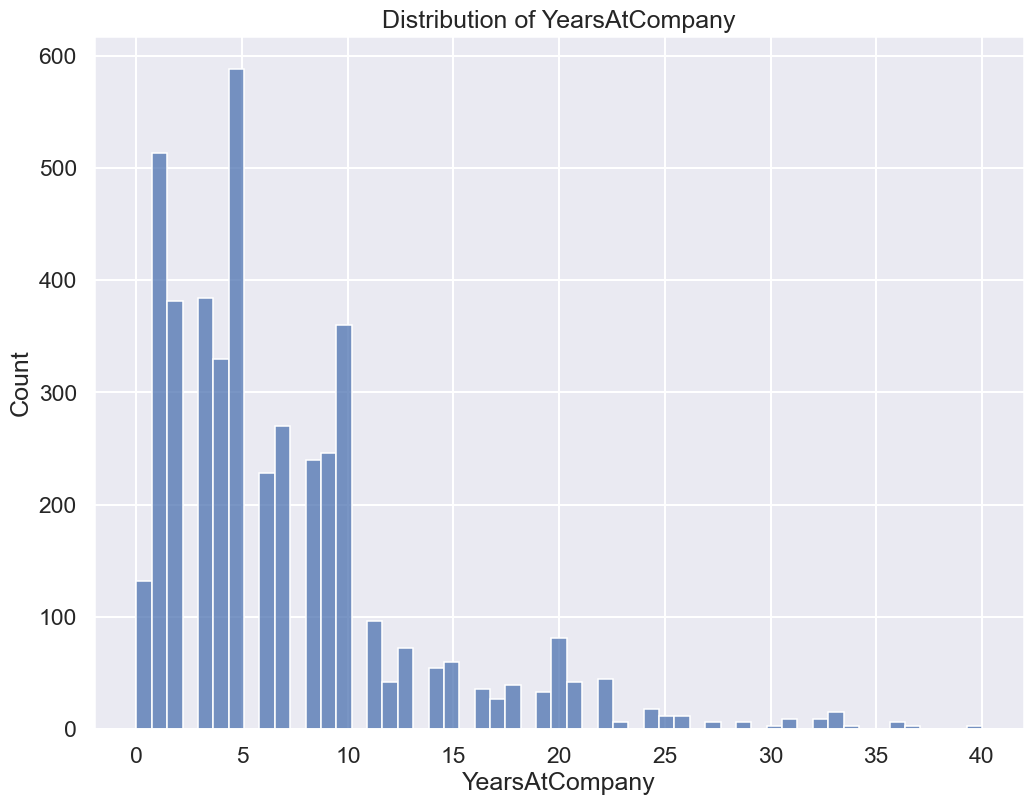

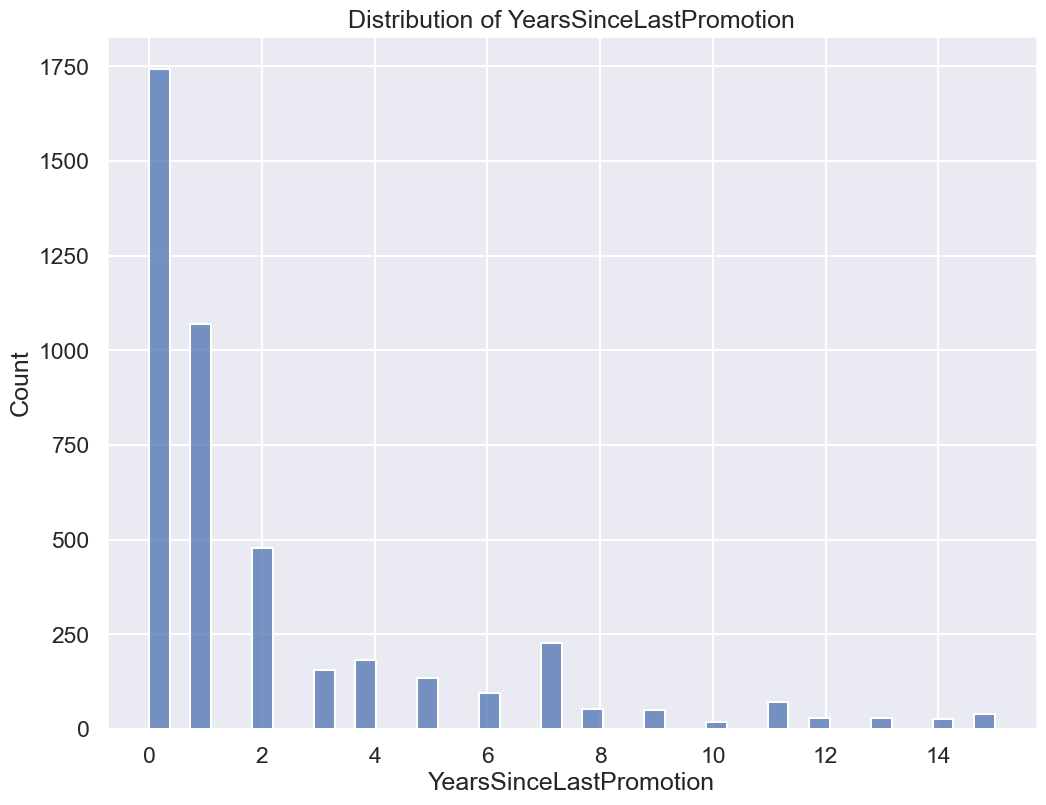

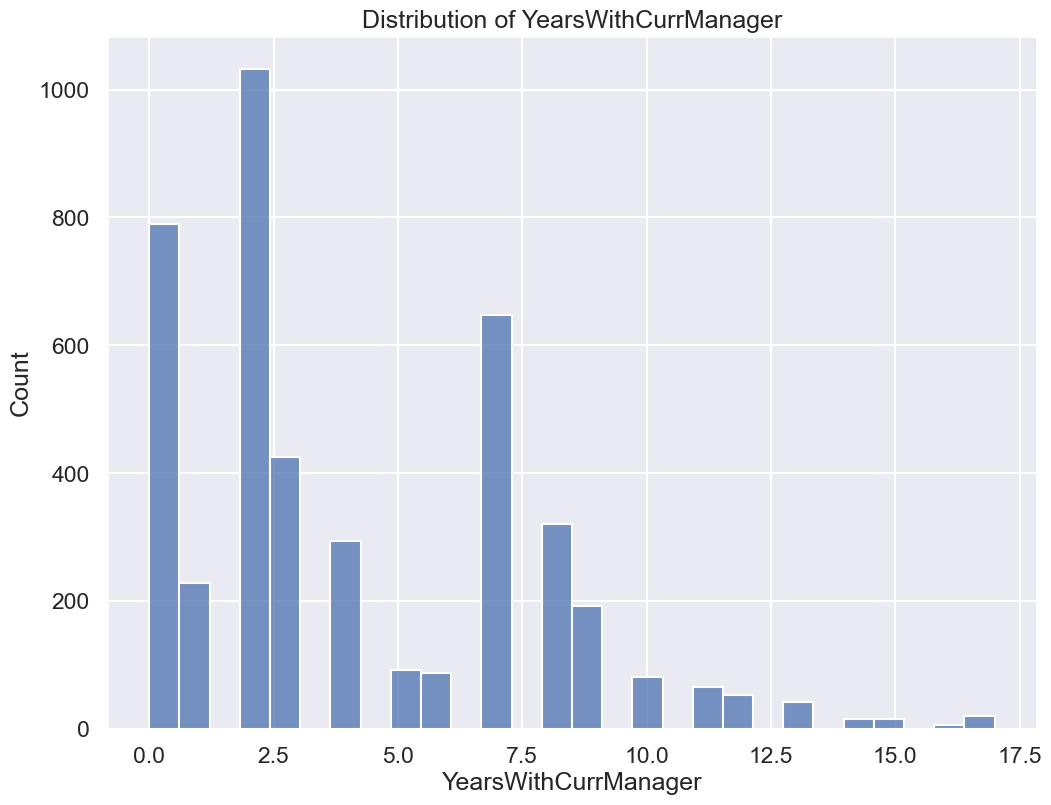

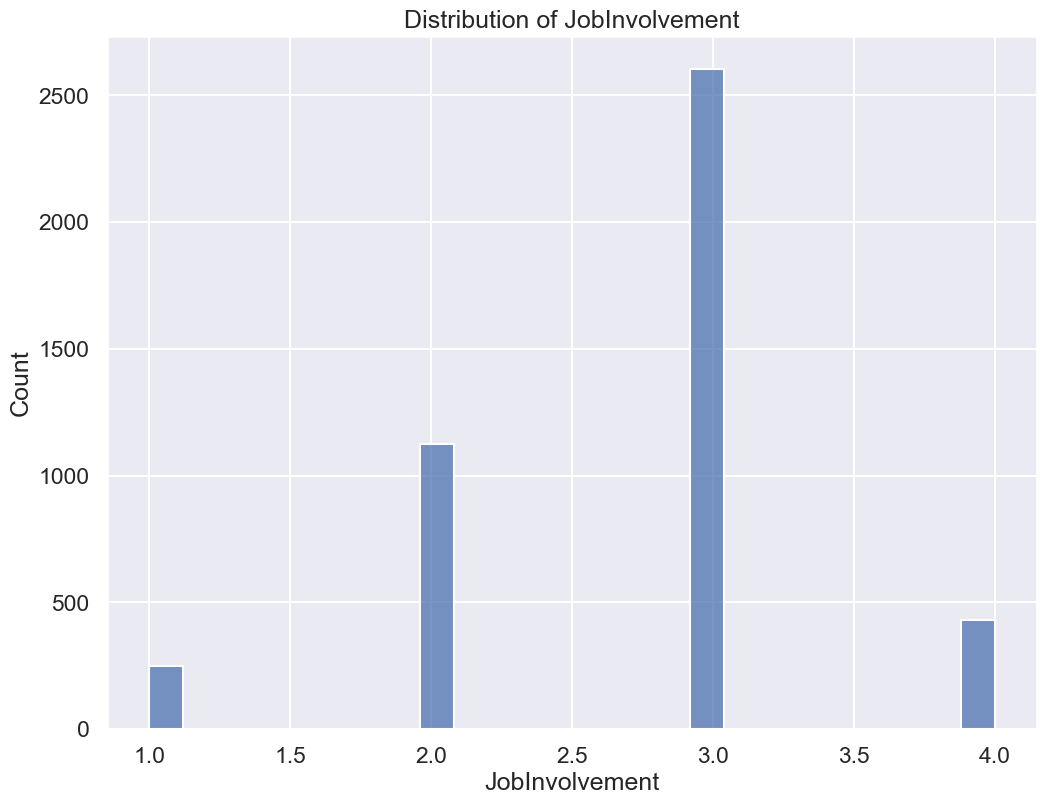

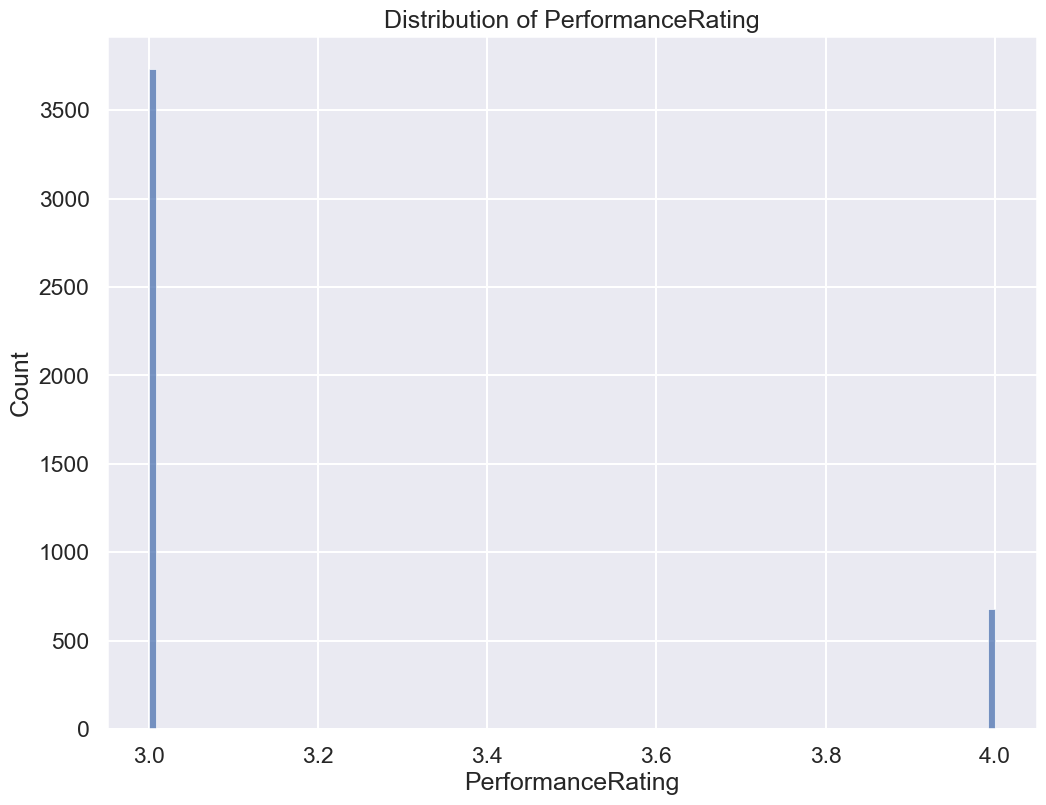

In [91]:
for column in numerical_cols:
    sns.histplot(data=employees_data, x=column)
    plt.title(f'Distribution of {column}')
    plt.show()

#### Univariate analysis for categorical features

<Axes: xlabel='Attrition', ylabel='count'>

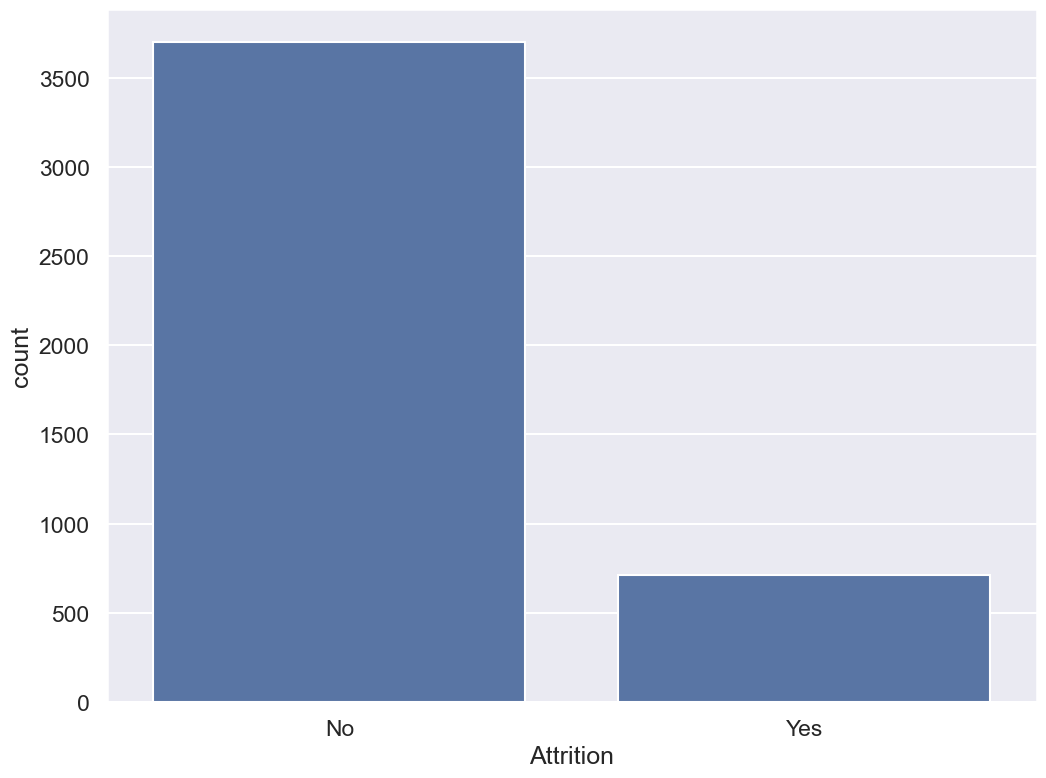

In [92]:
# for col in categorical_cols:
#     plt.figure(figsize=(10, 4))
#     sns.countplot(x=employees_data[col])
#     plt.title(f'Distribution of {col}')
#     plt.xticks(rotation=45)
#     plt.show()

sns.countplot(x=employees_data[categorical_cols[0]])

### 6. Bivariate analysis

#### Identify numerical and categorical columns

In [93]:
numerical_cols = employees_data.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = employees_data.select_dtypes(include=["object"]).columns
print('numerical columns', numerical_cols)
print('categorical columns', categorical_cols)

numerical columns Index(['EmployeeID', 'EnvironmentSatisfaction', 'JobSatisfaction',
       'WorkLifeBalance', 'Age', 'DistanceFromHome', 'Education', 'JobLevel',
       'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'JobInvolvement', 'PerformanceRating'],
      dtype='object')
categorical columns Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField',
       'JobRole', 'MaritalStatus'],
      dtype='object')


Use the **pairplot** to discover linear trends

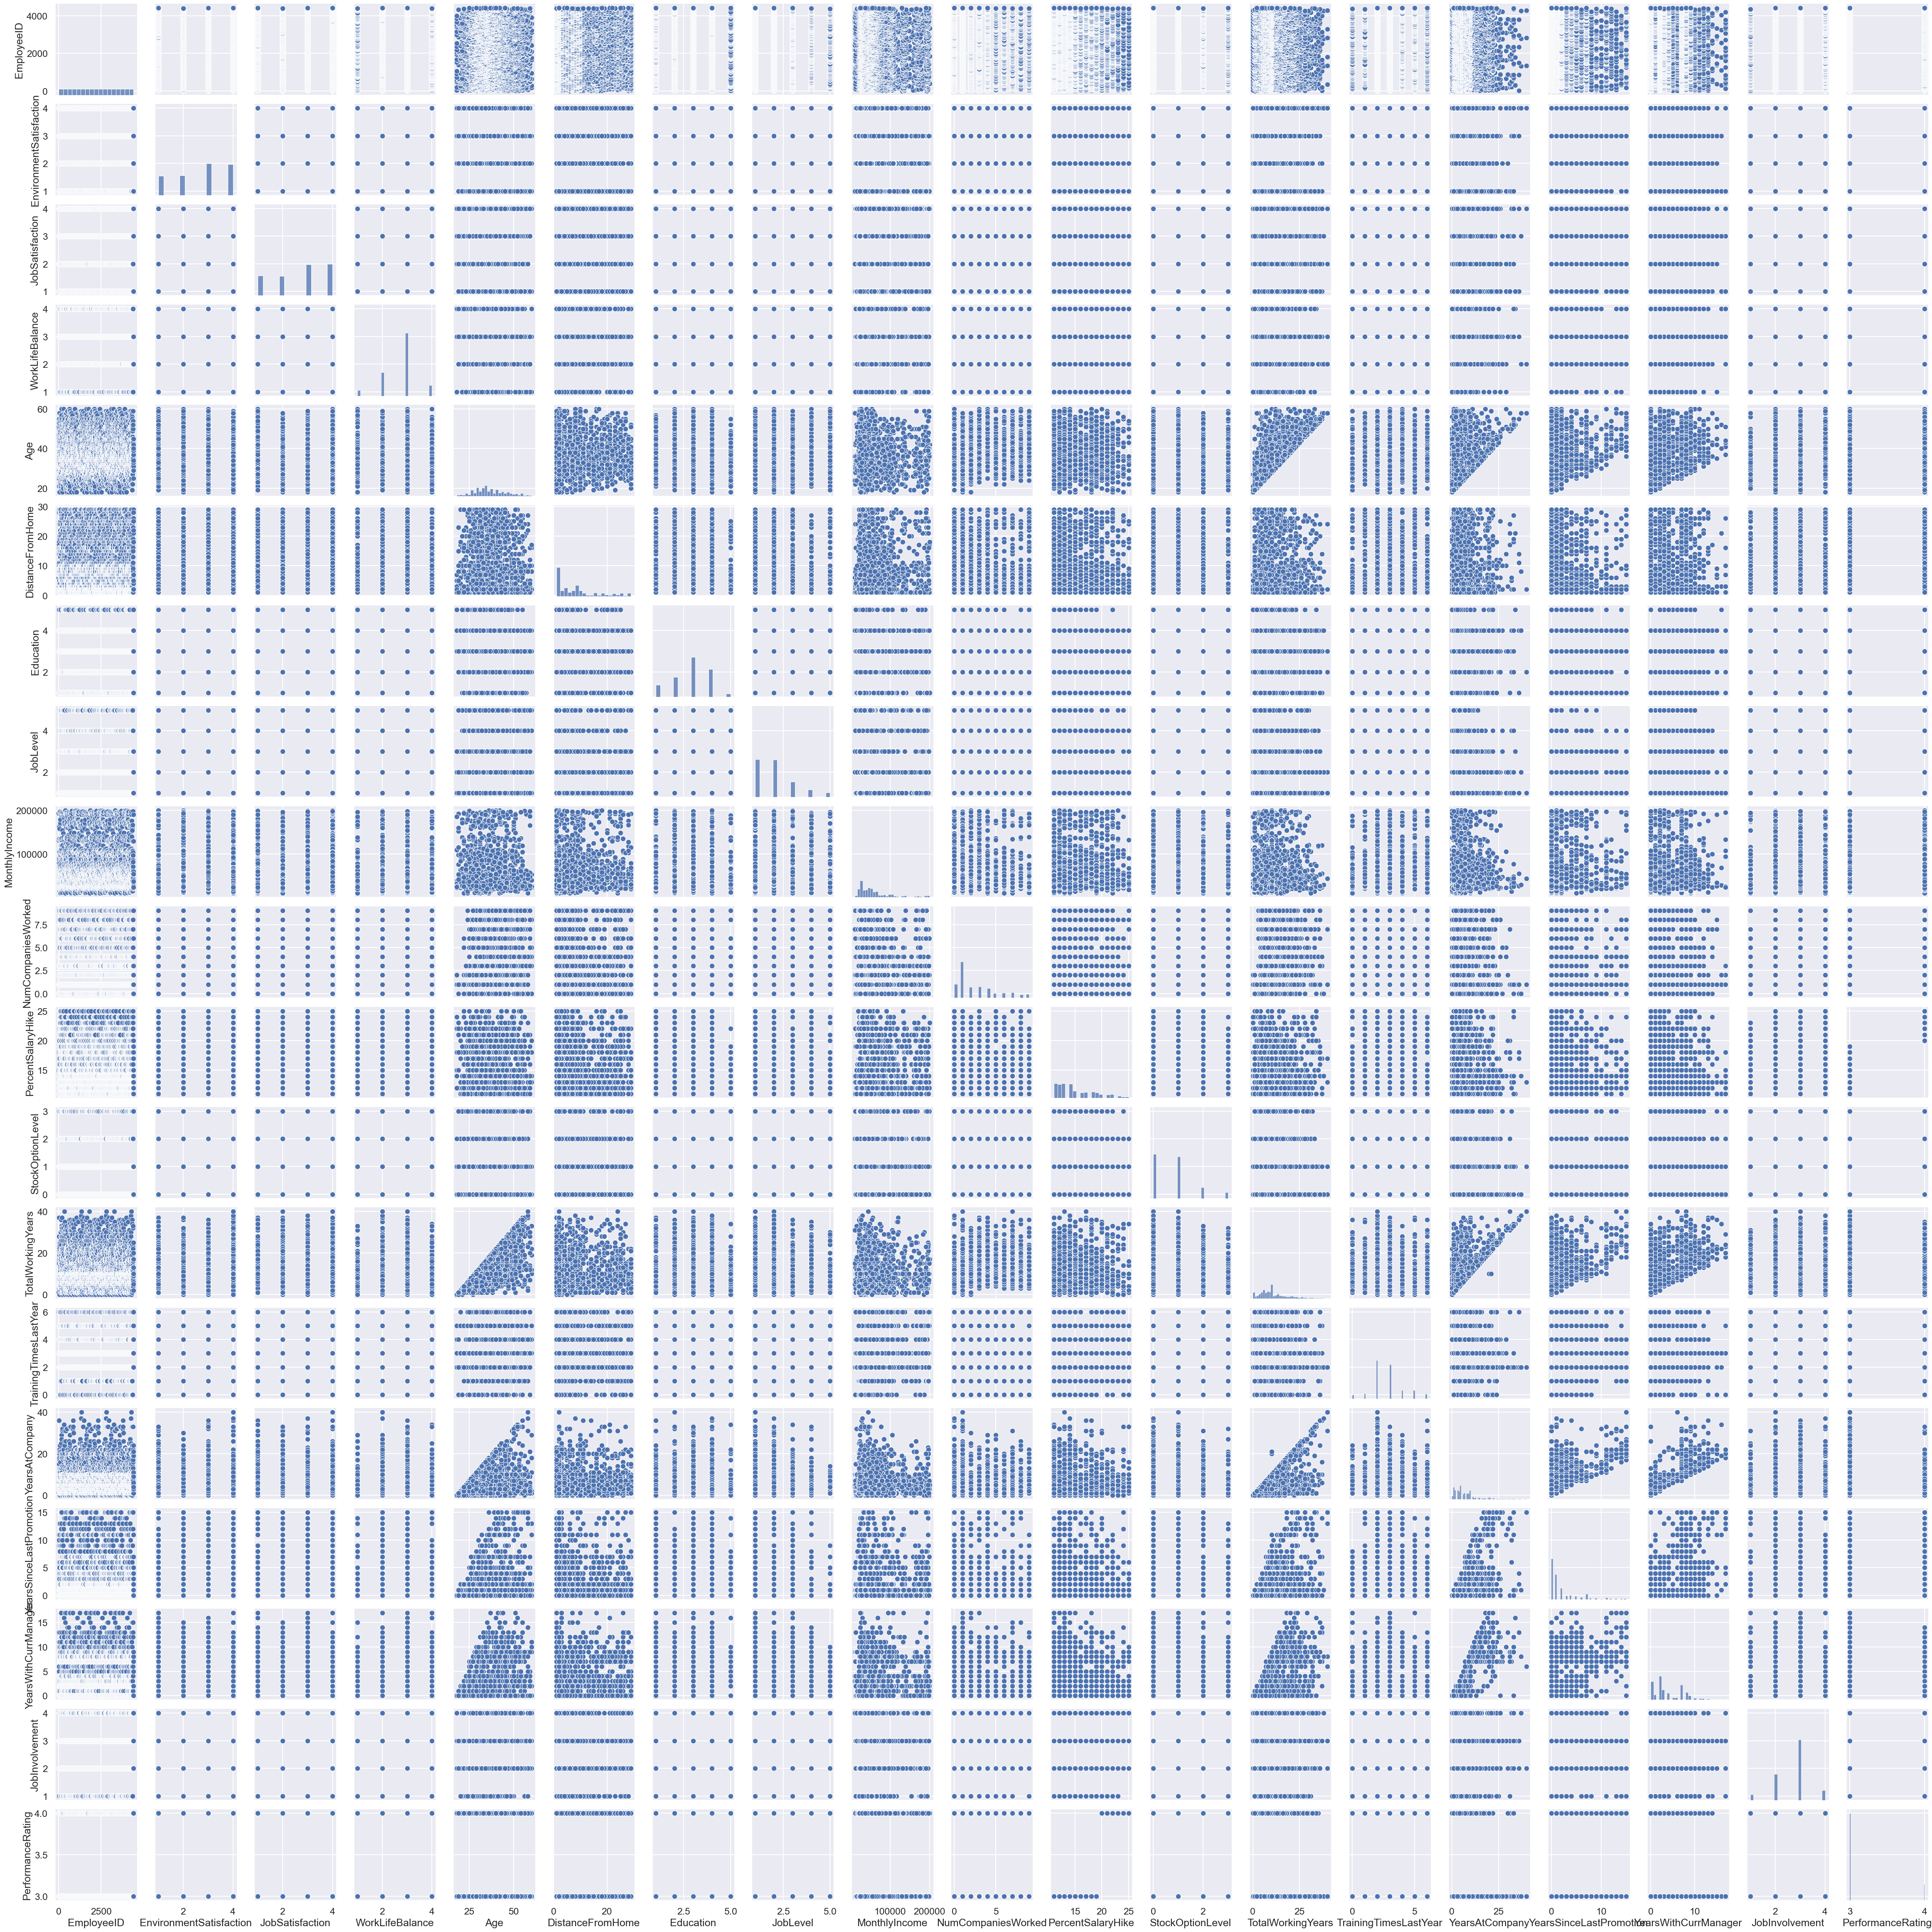

In [94]:
sns.pairplot(employees_data)
plt.show()

Using boxplots for categorical vs numerical features

C:\Users\hedir\AppData\Local\Temp\ipykernel_18012\2527027799.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


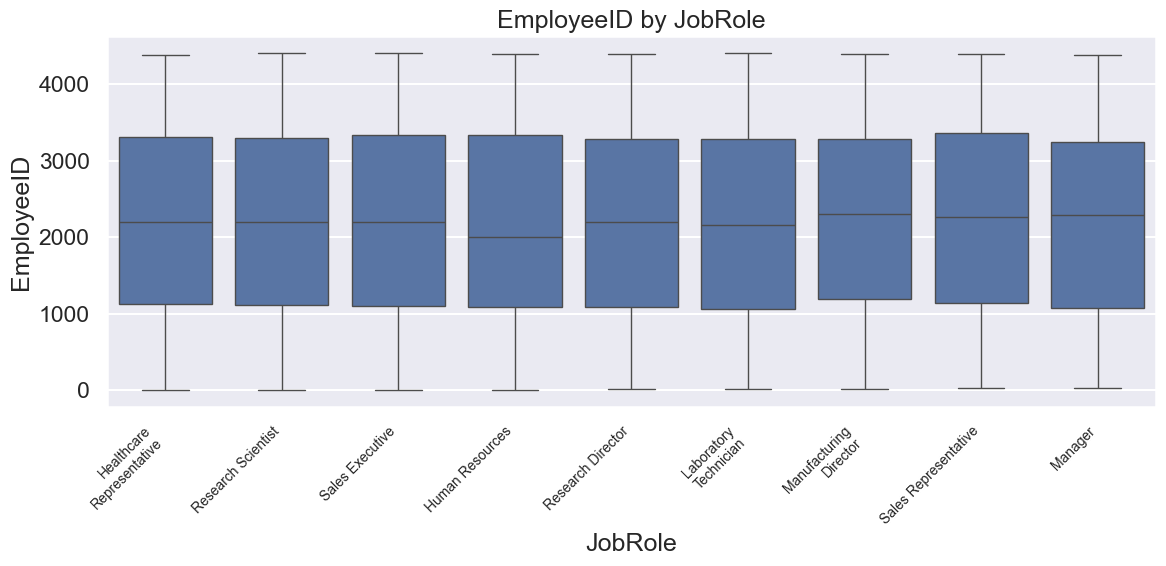

C:\Users\hedir\AppData\Local\Temp\ipykernel_18012\2527027799.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


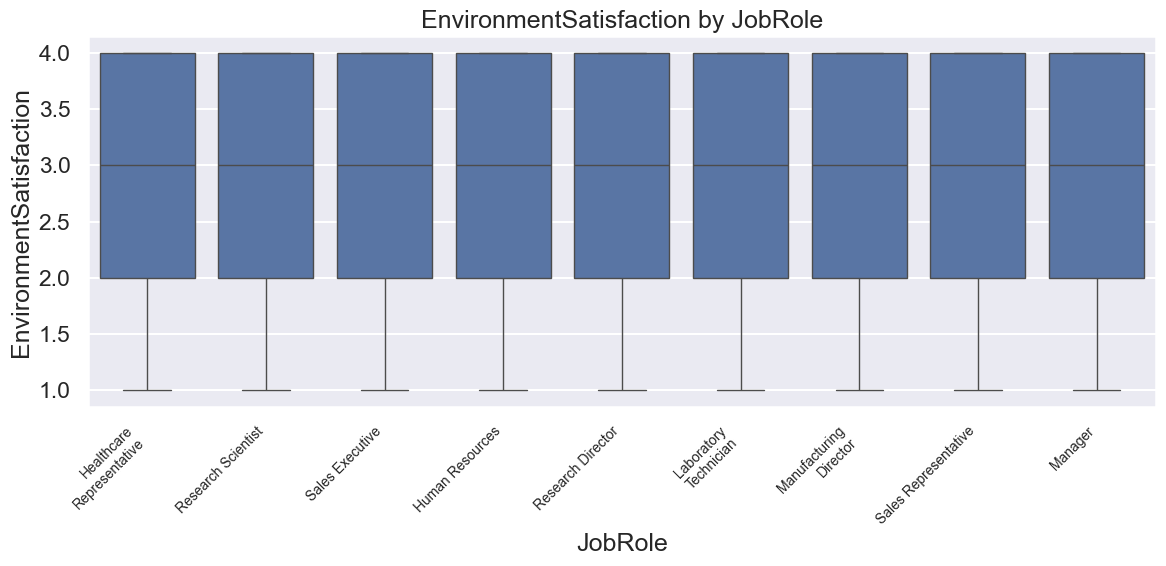

C:\Users\hedir\AppData\Local\Temp\ipykernel_18012\2527027799.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


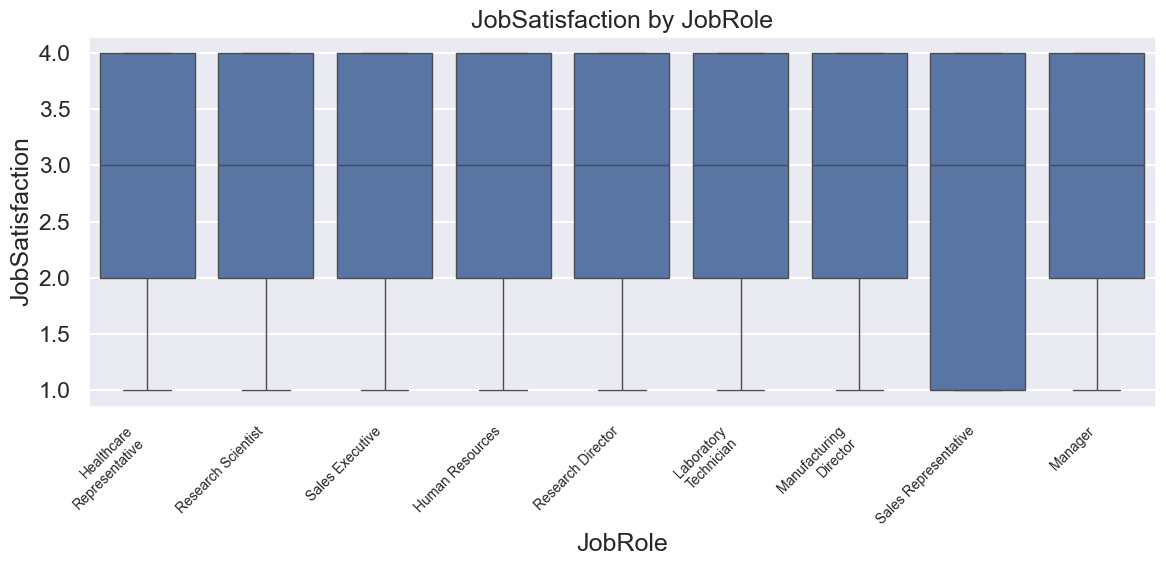

C:\Users\hedir\AppData\Local\Temp\ipykernel_18012\2527027799.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


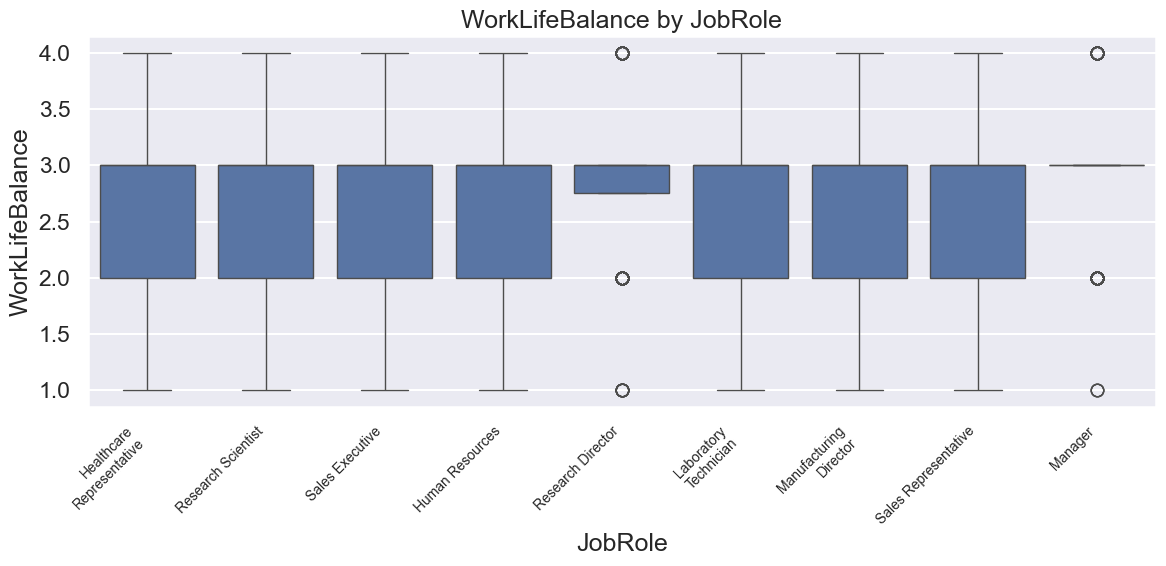

C:\Users\hedir\AppData\Local\Temp\ipykernel_18012\2527027799.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)


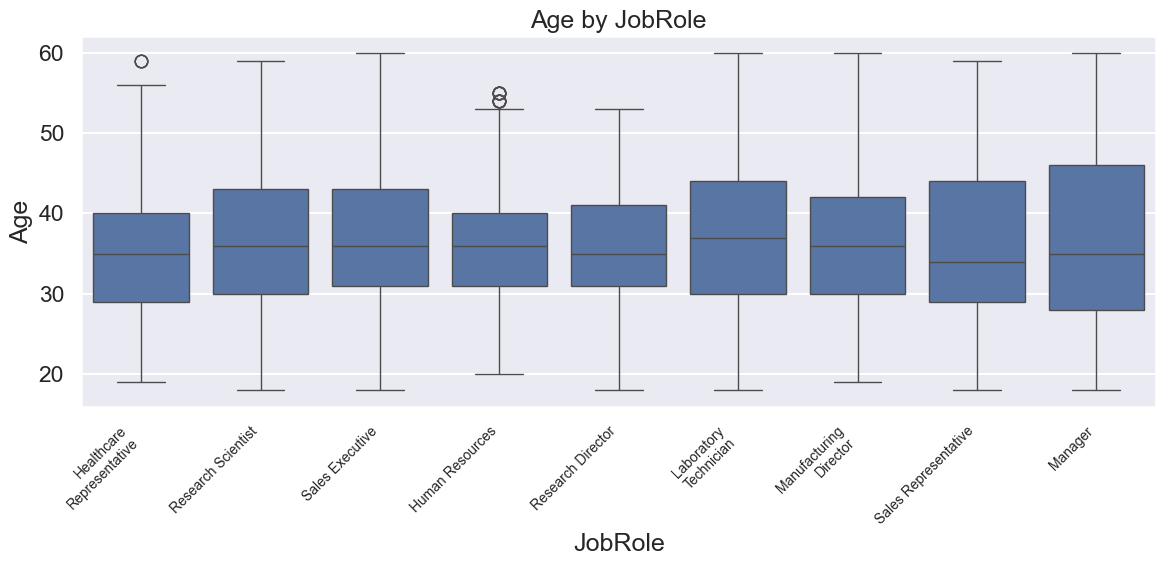

In [95]:
import textwrap

categorical_column = 'JobRole'

# Automatically choose orientation when there are many categories
n_categories = employees_data[categorical_column].nunique()

for numeric_value in numerical_cols[:5]:
    plt.figure(figsize=(12, 6))
    if n_categories > 10:
        # Use horizontal boxplot when many categories to improve label readability
        ax = sns.boxplot(y=employees_data[categorical_column], x=employees_data[numeric_value])
        plt.title(f'{numeric_value} by {categorical_column} (horizontal)')
        # Wrap long labels and set a readable fontsize
        labels = [textwrap.fill(t.get_text(), 30) for t in ax.get_yticklabels()]
        ax.set_yticklabels(labels, fontsize=10)
    else:
        ax = sns.boxplot(x=employees_data[categorical_column], y=employees_data[numeric_value])
        plt.title(f'{numeric_value} by {categorical_column}')
        # Wrap long labels, rotate and align to the right
        labels = [textwrap.fill(t.get_text(), 20) for t in ax.get_xticklabels()]
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)

    plt.tight_layout()
    plt.show()


Creating a correlation heatmap for some numerical features

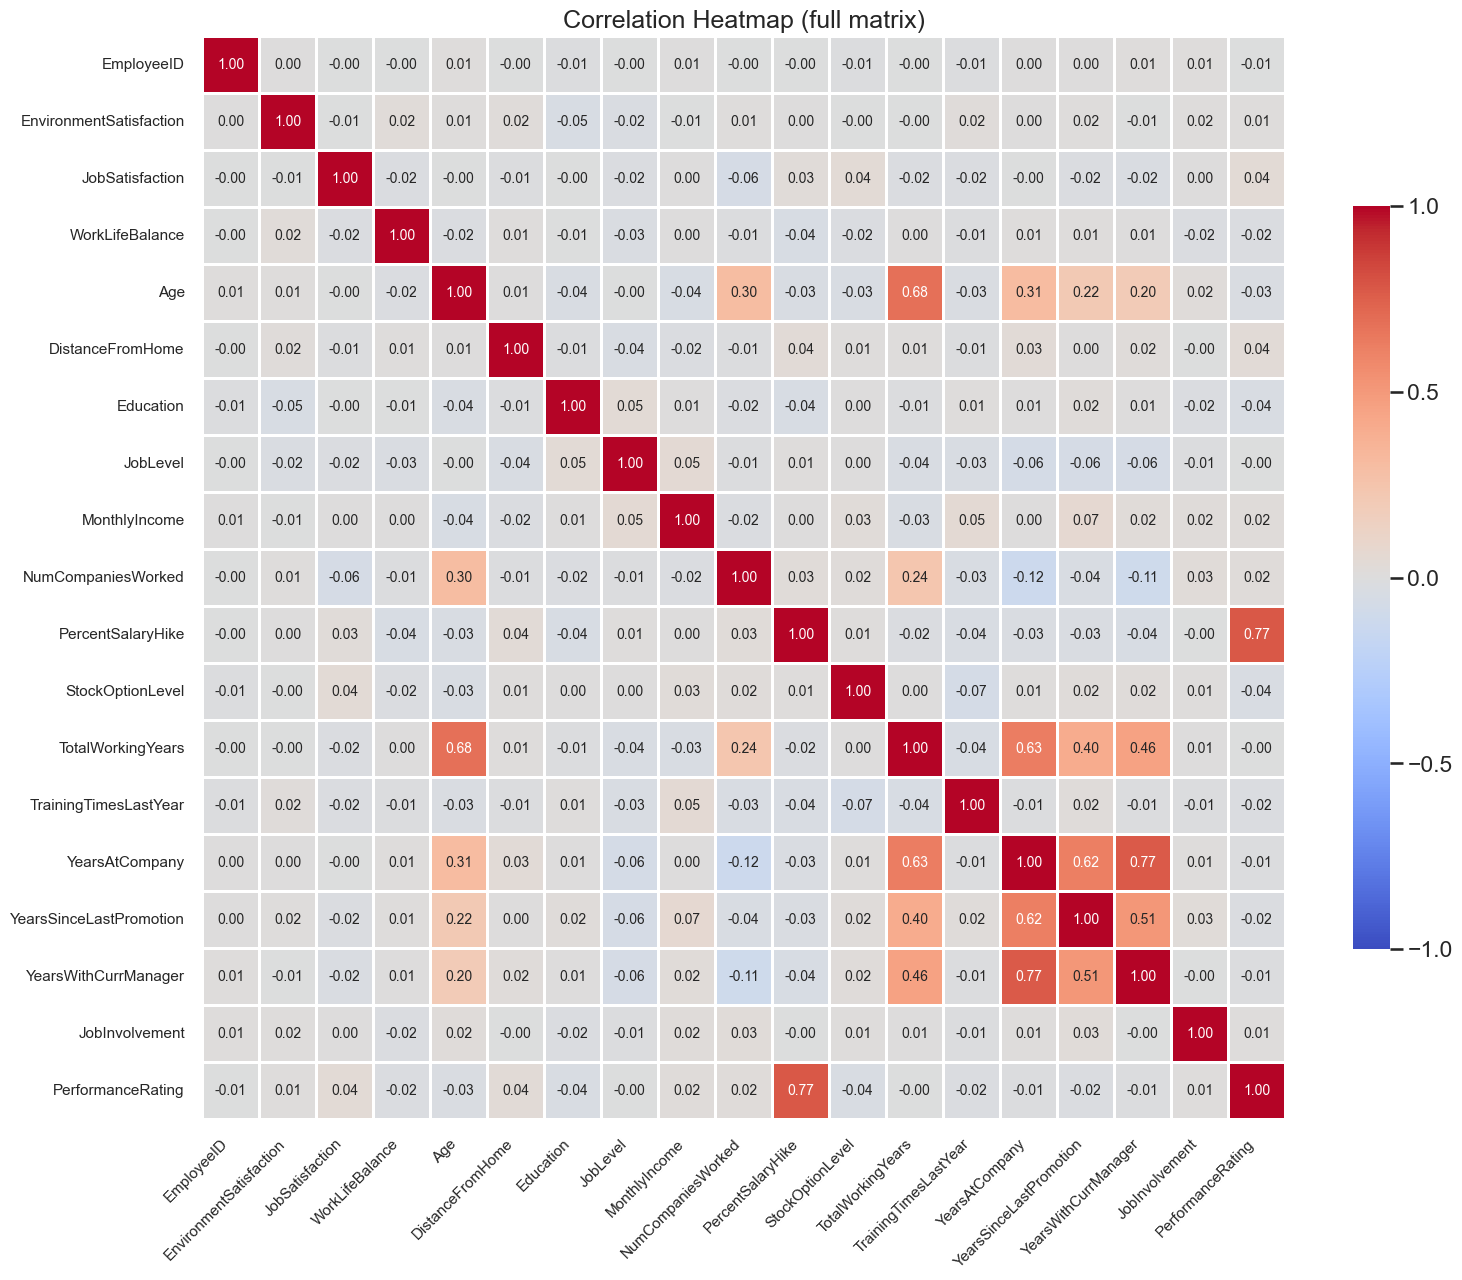

In [ ]:
import numpy as np

# Full correlation heatmap — improved readability without masking
plt.figure(figsize=(16, 14))

# Compute correlation (full matrix)
corr = employees_data[numerical_cols].corr()

# Draw heatmap without masking — make annotations and layout clearer
sns.set_style("white")
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.75,
    linecolor='white',
    square=True,
    annot_kws={"size": 10},
    cbar_kws={"shrink": 0.6, "ticks": [-1, -0.5, 0, 0.5, 1]}
)

# Improve tick label readability and spacing
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.title('Correlation Heatmap')
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


Job Info